# Laboratorio 4: análisis de datos geoespaciales — lagos Atitlán y Amatitlán

Este notebook implementa el flujo completo de adquisición y análisis para los lagos Atitlán y Amatitlán usando Sentinel-2 L2A mediante openEO. Se utilizan únicamente las fechas oficiales de la guía.

**Ejercicios cubiertos:** 1) conexión a la API, 2) obtención de datos, 3) cálculo de NDVI, NDWI y NDCI para cianobacterias, 4) análisis temporal (promedio por lago y fecha), 5) análisis espacial (mapas interactivos y comparativos), 6) correlación de NDVI/NDWI con la cianobacteria, 7) comparación entre lagos, y 8) análisis exploratorio adicional (extensión espacial, zonas persistentes, distribución entre fechas y patrón estacional).

El NDCI es el índice cuantitativo de cianobacterias utilizado en el script de Sentinel Hub: `(B05 - B04) / (B05 + B04)`. Se reporta como indicador espectral de clorofila-a/cianobacterias y no como una medición de laboratorio.

## 0. Dependencias y configuración

Si alguna dependencia no está instalada, ejecute `pip install openeo rasterio geopandas shapely numpy pandas matplotlib` en el entorno del notebook. La autenticación OIDC se realiza en el navegador y requiere una cuenta de Copernicus Data Space.

In [1]:
from datetime import date, timedelta
from pathlib import Path
import warnings

import folium
import geopandas as gpd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import openeo
import pandas as pd
import rasterio
from branca.colormap import LinearColormap
from rasterio.features import geometry_mask
from rasterio.transform import array_bounds
from rasterio.warp import Resampling as WarpResampling
from rasterio.warp import calculate_default_transform, reproject
from shapely.geometry import box

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 30)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "GIS" / "lab4_avance"
DATA_DIR.mkdir(parents=True, exist_ok=True)
API_URL = "https://openeo.dataspace.copernicus.eu"
COLLECTION = "SENTINEL2_L2A"
# Las bandas se solicitan en el mismo orden en que se interpretan localmente.
BANDS = ["B02", "B03", "B04", "B05", "B08", "SCL"]
NDCI_HIGH_THRESHOLD = 0.20
print(f"Datos de salida: {DATA_DIR.resolve()}")

/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Datos de salida: /Users/dijan/Documents/U/Data Science/Lab4/data/GIS/lab4_avance


## 1. Áreas y fechas oficiales

Las extensiones corresponden a la guía del laboratorio. Para cada fecha se solicita una ventana de un día, porque openEO espera un intervalo temporal y la fecha final es exclusiva en muchos backends.

In [2]:
LAKES = {
    "Atitlan": {
        "west": -91.326256, "east": -91.07151,
        "south": 14.5948, "north": 14.750979,
    },
    "Amatitlan": {
        "west": -90.638065, "east": -90.512924,
        "south": 14.412347, "north": 14.493799,
    },
}

OFFICIAL_DATES = {
    "Atitlan": [
        "2025-01-18", "2025-04-13", "2025-05-13",
        "2025-07-17", "2025-11-21", "2025-12-29",
        "2026-02-12", "2026-03-24", "2026-04-13",
        "2026-04-28", "2026-07-22",
    ],
    "Amatitlan": [
        "2025-01-28", "2025-04-15", "2025-04-28",
        "2025-11-24", "2026-01-08", "2026-02-02",
        "2026-02-07", "2026-03-29", "2026-04-13",
        "2026-04-28", "2026-06-19",
    ],
}

assert set(LAKES) == set(OFFICIAL_DATES)
assert all(len(v) == 11 for v in OFFICIAL_DATES.values())
print("Configuración validada: 2 lagos y 11 fechas oficiales por lago.")

Configuración validada: 2 lagos y 11 fechas oficiales por lago.


## 2. Geometrías de trabajo

Si existe un GeoJSON proporcionado por el curso, se utiliza para calcular estadísticas solamente sobre el cuerpo de agua. Como respaldo reproducible, el notebook construye un polígono con el bounding box oficial. El respaldo permite ejecutar el flujo, pero para la entrega final se debe preferir el GeoJSON, porque el bounding box incluye tierra.

In [3]:
def find_lake_geometry(lake_name, extent):
    candidates = [
        p for p in list(BASE_DIR.rglob("*.geojson")) + list(BASE_DIR.rglob("*.json"))
        if not any(part.startswith(".") or part in ("data",) for part in p.relative_to(BASE_DIR).parts[:-1])
        and lake_name.lower() in p.name.lower()
    ]
    for path in candidates:
        try:
            frame = gpd.read_file(path)
            if frame.empty or frame.geometry.isna().any() or frame.geometry.is_empty.any():
                continue
            frame = frame.to_crs("EPSG:4326")
            return frame[["geometry"]], f"GeoJSON: {path.name}"
        except Exception:
            continue
    fallback = gpd.GeoDataFrame(
        {"geometry": [box(extent["west"], extent["south"], extent["east"], extent["north"])]},
        crs="EPSG:4326",
    )
    return fallback, "Bounding box oficial (respaldo)"

GEOMETRIES = {}
for lake_name, extent in LAKES.items():
    GEOMETRIES[lake_name], source = find_lake_geometry(lake_name, extent)
    print(f"{lake_name}: {source}")

Atitlan: Bounding box oficial (respaldo)


Amatitlan: Bounding box oficial (respaldo)


## Ejercicio 1. Conexión con openEO

La siguiente celda abre la conexión y ejecuta OIDC. No se guardan credenciales en el notebook.

In [4]:
connection = openeo.connect(API_URL)
connection = connection.authenticate_oidc()
print(f"Conexión autenticada: {API_URL}")
print("Backend: ", connection.describe_account())

Authenticated using refresh token.
Conexión autenticada: https://openeo.dataspace.copernicus.eu


Backend:  {'info': {'oidc_userinfo': {'email': 'pad23663@uvg.edu.gt', 'email_verified': True, 'family_name': 'Padilla', 'given_name': 'Luis', 'name': 'Luis Padilla', 'preferred_username': 'pad23663@uvg.edu.gt', 'sub': '6d5c54ba-eb01-45fb-b63a-42c48bbcf64c'}}, 'name': 'Luis Padilla', 'user_id': '6d5c54ba-eb01-45fb-b63a-42c48bbcf64c'}


## Ejercicio 2. Descarga de escenas Sentinel-2 L2A

Se descarga una escena por lago y fecha. Se incluyen B02-B05 y B08 para los índices, y SCL para excluir píxeles de nubes, sombras y datos inválidos. Los GeoTIFF se conservan localmente para que el análisis sea reproducible sin volver a consultar la API.

In [5]:
def scene_path(lake_name, date_text):
    return DATA_DIR / f"{lake_name}_{date_text}.tif"

def download_scene(connection, lake_name, date_text):
    target = scene_path(lake_name, date_text)
    if target.exists() and target.stat().st_size > 0:
        return target
    start = date.fromisoformat(date_text)
    end = start + timedelta(days=1)
    cube = connection.load_collection(
        COLLECTION,
        spatial_extent=LAKES[lake_name],
        temporal_extent=[start.isoformat(), end.isoformat()],
        bands=BANDS,
    )
    job = connection.create_job(
        cube.save_result(format="GTIFF"),
        title=f"Lab4_{lake_name}_{date_text}",
    )
    job.start_and_wait()
    job.download_results(str(target))
    if not target.exists():
        raise FileNotFoundError(f"openEO no creó {target}")
    return target

scene_files = []
for lake_name in LAKES:
    for date_text in OFFICIAL_DATES[lake_name]:
        path = download_scene(connection, lake_name, date_text)
        scene_files.append((lake_name, date_text, path))
        print(f"Disponible: {path.name}")
print(f"Escenas disponibles: {len(scene_files)}")

Disponible: Atitlan_2025-01-18.tif
Disponible: Atitlan_2025-04-13.tif
Disponible: Atitlan_2025-05-13.tif
Disponible: Atitlan_2025-07-17.tif
Disponible: Atitlan_2025-11-21.tif
Disponible: Atitlan_2025-12-29.tif
Disponible: Atitlan_2026-02-12.tif
Disponible: Atitlan_2026-03-24.tif
Disponible: Atitlan_2026-04-13.tif
Disponible: Atitlan_2026-04-28.tif
Disponible: Atitlan_2026-07-22.tif
Disponible: Amatitlan_2025-01-28.tif
Disponible: Amatitlan_2025-04-15.tif
Disponible: Amatitlan_2025-04-28.tif
Disponible: Amatitlan_2025-11-24.tif
Disponible: Amatitlan_2026-01-08.tif
Disponible: Amatitlan_2026-02-02.tif
Disponible: Amatitlan_2026-02-07.tif
Disponible: Amatitlan_2026-03-29.tif
Disponible: Amatitlan_2026-04-13.tif
Disponible: Amatitlan_2026-04-28.tif
Disponible: Amatitlan_2026-06-19.tif
Escenas disponibles: 22


## Ejercicio 3. Preprocesamiento e índices espectrales

Las expresiones se calculan píxel a píxel: NDVI para vegetación, NDWI para agua y NDCI para clorofila-a/cianobacterias. Se utiliza SCL para descartar nodata, sombras y nubes; además, la geometría del lago limita el cálculo espacial.

In [6]:
def safe_normalized_difference(a, b):
    denominator = a + b
    return np.divide(a - b, denominator, out=np.full_like(a, np.nan, dtype=np.float32), where=denominator != 0)

def read_scene(path, lake_name):
    with rasterio.open(path) as src:
        raw = src.read()
        transform = src.transform
        crs = src.crs
        descriptions = list(src.descriptions)
    names = [d.upper() if d else BANDS[i] for i, d in enumerate(descriptions)]
    band_map = {name: raw[i] for i, name in enumerate(names)}
    missing = set(BANDS) - set(band_map)
    if missing:
        raise ValueError(f"Faltan bandas {missing} en {path.name}; descripciones={descriptions}")
    scale = {name: band_map[name].astype(np.float32) / 10000.0 for name in BANDS if name != "SCL"}
    ndvi = safe_normalized_difference(scale["B08"], scale["B04"])
    ndwi = safe_normalized_difference(scale["B03"], scale["B08"])
    ndci = safe_normalized_difference(scale["B05"], scale["B04"])
    scl = band_map["SCL"]
    # SCL: 0 nodata, 1 saturado, 3 sombra, 8-10 nubes, 11 nieve/hielo.
    clear = ~np.isin(scl, [0, 1, 3, 8, 9, 10, 11])
    geometry = GEOMETRIES[lake_name].to_crs(crs)
    inside = geometry_mask(geometry.geometry, out_shape=ndci.shape, transform=transform, invert=True)
    valid = clear & inside & np.isfinite(ndci) & np.isfinite(ndvi) & np.isfinite(ndwi)
    return {
        "ndvi": ndvi, "ndwi": ndwi, "ndci": ndci, "valid": valid, "inside": inside, "clear": clear,
        "transform": transform, "crs": crs,
    }

def summarize_scene(indices, lake_name, date_text):
    mask = indices["valid"]
    ndci = indices["ndci"][mask]
    ndvi = indices["ndvi"][mask]
    ndwi = indices["ndwi"][mask]
    if ndci.size == 0:
        raise ValueError(f"No hay píxeles válidos para {lake_name} {date_text}")
    return {
        "lake": lake_name, "date": pd.Timestamp(date_text),
        "ndci_mean": float(np.mean(ndci)),
        "ndci_median": float(np.median(ndci)),
        "ndci_p90": float(np.percentile(ndci, 90)),
        "ndci_high_fraction": float(np.mean(ndci >= NDCI_HIGH_THRESHOLD)),
        "ndvi_mean": float(np.mean(ndvi)),
        "ndwi_mean": float(np.mean(ndwi)),
        "valid_pixels": int(ndci.size),
        "clear_fraction": float(np.mean(indices["clear"][indices["inside"]])) ,
    }

In [7]:
# Verificación local de fórmulas y manejo de división por cero.
a = np.array([[0.2, 0.0]], dtype=np.float32)
b = np.array([[0.4, 0.0]], dtype=np.float32)
assert np.isclose(safe_normalized_difference(b, a)[0, 0], 1 / 3)
assert np.isnan(safe_normalized_difference(b, a)[0, 1])
print("Verificación matemática aprobada: NDVI, NDWI y NDCI usan diferencias normalizadas seguras.")

Verificación matemática aprobada: NDVI, NDWI y NDCI usan diferencias normalizadas seguras.


In [8]:
records = []
processed = {}
for lake_name, date_text, path in scene_files:
    indices = read_scene(path, lake_name)
    processed[(lake_name, date_text)] = indices
    records.append(summarize_scene(indices, lake_name, date_text))

summary = pd.DataFrame(records).sort_values(["lake", "date"]).reset_index(drop=True)
summary.to_csv(DATA_DIR / "resumen_indices_por_fecha.csv", index=False)
summary.head()

,lake,date,ndci_mean,ndci_median,ndci_p90,ndci_high_fraction,ndvi_mean,ndwi_mean,valid_pixels,clear_fraction
0,Amatitlan,2025-01-28,0.302629,0.305085,0.524265,0.701021,0.460876,-0.429267,1217013,0.999990
1,Amatitlan,2025-04-15,0.228148,0.217391,0.439294,0.535146,0.423703,-0.413477,1217043,1.000000
2,Amatitlan,2025-04-28,0.220848,0.210395,0.429434,0.520693,0.424725,-0.411800,1215819,0.998994
3,Amatitlan,2025-11-24,0.350760,0.394758,0.559406,0.754791,0.544046,-0.483031,1212925,0.996616
4,Amatitlan,2026-01-08,0.353578,0.378641,0.579240,0.765935,0.533002,-0.480009,1217043,1.000000


### Visualización de índices

Se muestran las tres capas para la primera fecha disponible de cada lago. Los mapas tienen la misma escala para facilitar la comparación.

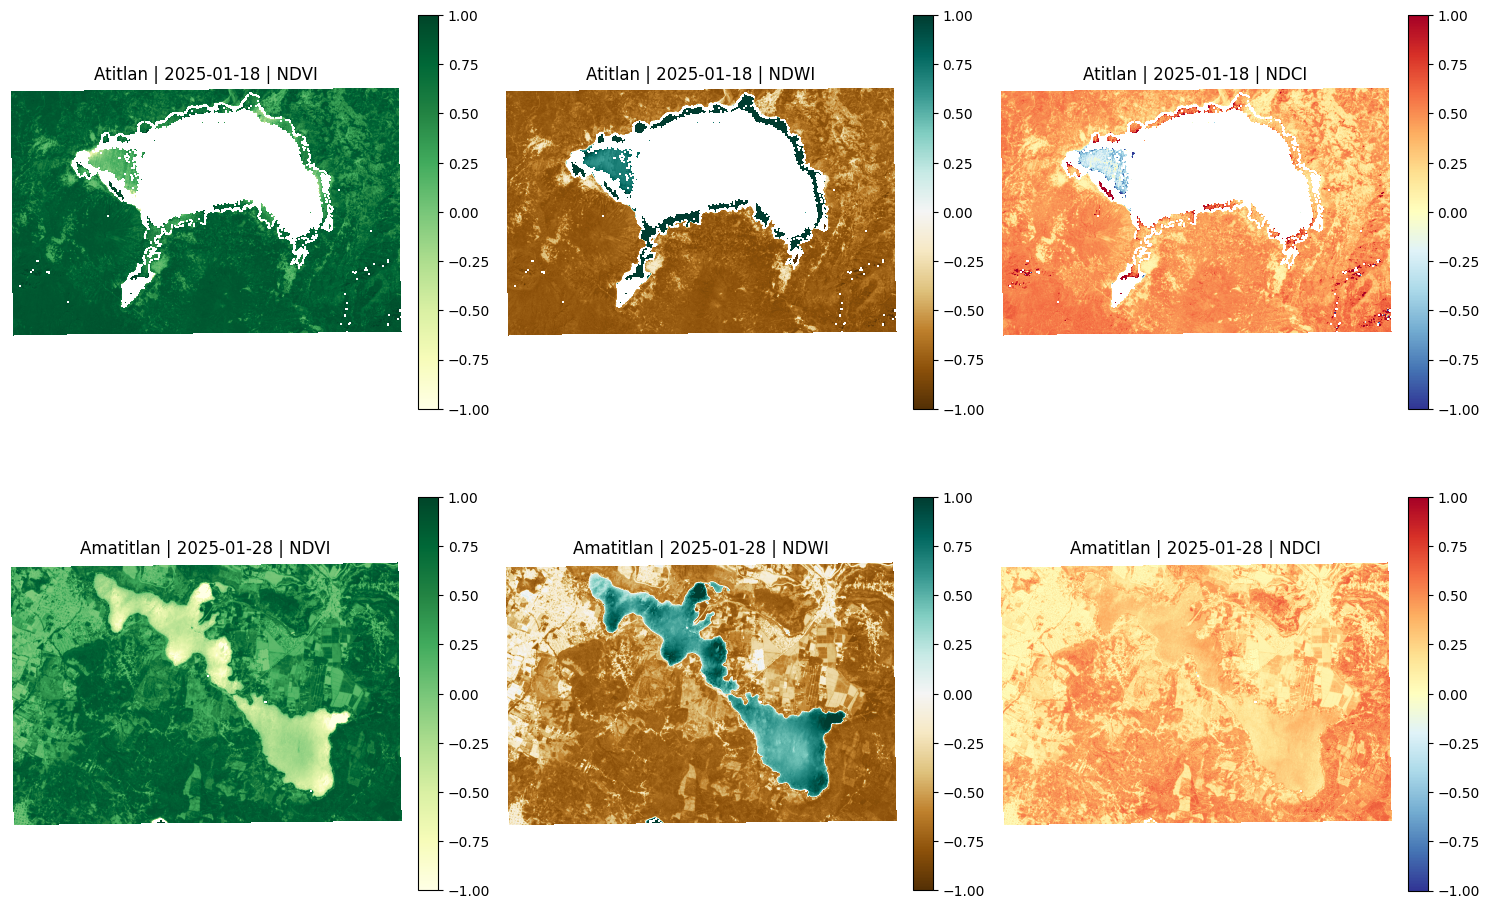

In [9]:
fig, axes = plt.subplots(len(LAKES), 3, figsize=(15, 5 * len(LAKES)), squeeze=False)
for row, lake_name in enumerate(LAKES):
    first_date = OFFICIAL_DATES[lake_name][0]
    indices = processed[(lake_name, first_date)]
    for col, (name, cmap, limits) in enumerate([
        ("ndvi", "YlGn", (-1, 1)), ("ndwi", "BrBG", (-1, 1)), ("ndci", "RdYlBu_r", (-1, 1))
    ]):
        image = np.where(indices["valid"], indices[name], np.nan)
        plot = axes[row, col].imshow(image, cmap=cmap, vmin=limits[0], vmax=limits[1])
        axes[row, col].set_title(f"{lake_name} | {first_date} | {name.upper()}")
        axes[row, col].axis("off")
        fig.colorbar(plot, ax=axes[row, col], fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(DATA_DIR / "indices_muestra.png", dpi=150, bbox_inches="tight")
plt.show()

## Ejercicio 4. Análisis temporal

La métrica principal es el promedio de NDCI sobre los píxeles válidos de cada lago y fecha. La mediana, percentil 90, fracción de píxeles altos y promedios NDVI/NDWI se conservan como soporte para interpretar los resultados. El umbral de 0.20 se usa solo como indicador exploratorio de valores altos; no equivale por sí mismo a una concentración clínica o de laboratorio.

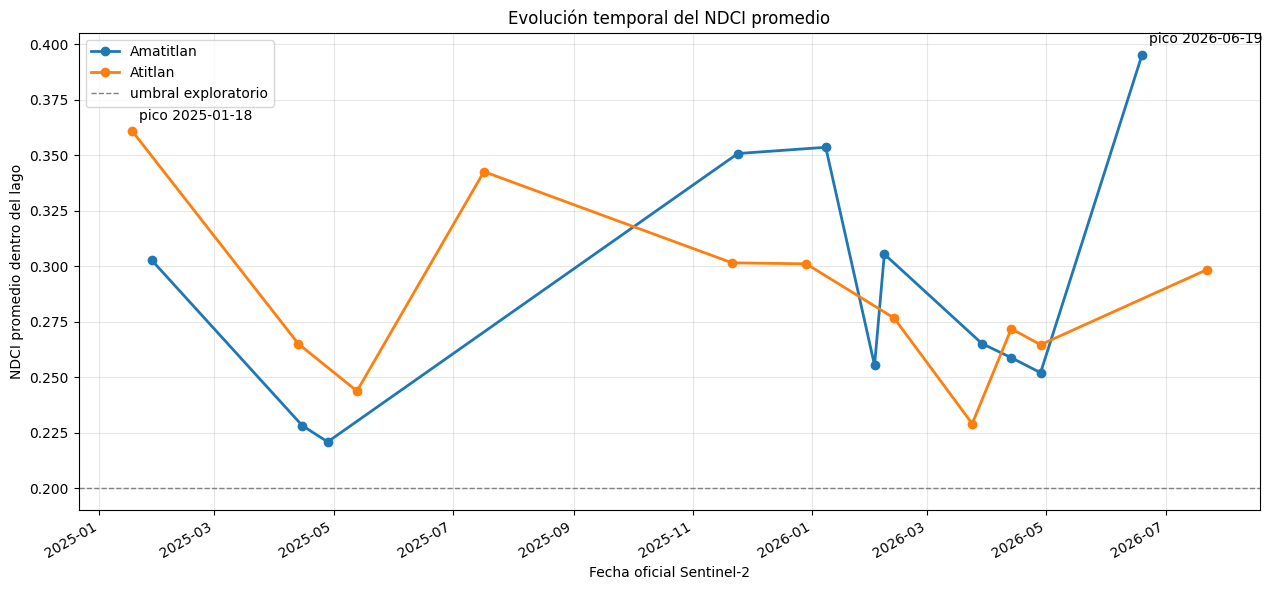

Fechas con mayor NDCI promedio por lago:


,lake,date,ndci_mean
10,Amatitlan,2026-06-19,0.395384
11,Atitlan,2025-01-18,0.360786


Resultados guardados en: /Users/dijan/Documents/U/Data Science/Lab4/data/GIS/lab4_avance


In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
for lake_name, group in summary.groupby("lake"):
    group = group.sort_values("date")
    ax.plot(group["date"], group["ndci_mean"], marker="o", linewidth=2, label=lake_name)
    peak = group.loc[group["ndci_mean"].idxmax()]
    ax.annotate(f"pico {peak.date:%Y-%m-%d}", (peak.date, peak.ndci_mean), xytext=(5, 8), textcoords="offset points")
ax.axhline(NDCI_HIGH_THRESHOLD, color="gray", linestyle="--", linewidth=1, label="umbral exploratorio")
ax.set_title("Evolución temporal del NDCI promedio")
ax.set_xlabel("Fecha oficial Sentinel-2")
ax.set_ylabel("NDCI promedio dentro del lago")
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(DATA_DIR / "serie_temporal_ndci.png", dpi=150, bbox_inches="tight")
plt.show()

peaks = summary.loc[summary.groupby("lake")["ndci_mean"].idxmax(), ["lake", "date", "ndci_mean"]]
print("Fechas con mayor NDCI promedio por lago:")
display(peaks)
print(f"Resultados guardados en: {DATA_DIR.resolve()}")

## Interpretación que debe acompañar al avance

La tabla y la gráfica permiten identificar fechas de mayor NDCI, pero no demuestran causalidad ambiental. En el informe se debe indicar qué lago presenta valores promedio mayores, qué fechas son críticas y si la serie aumenta, disminuye o fluctúa. También se debe reportar la cobertura válida y advertir si se utilizó el bounding box como respaldo en lugar del GeoJSON.

Los archivos producidos son `resumen_indices_por_fecha.csv`, `indices_muestra.png` y `serie_temporal_ndci.png` dentro de `data/GIS/lab4_avance`.

## Ejercicio 5. Análisis espacial

Para comparar píxeles entre fechas (mapas de diferencia, zonas persistentes) se necesita que todas las fechas de un mismo lago compartan exactamente la misma grilla espacial. Como cada descarga de openEO puede generar una rejilla ligeramente distinta, primero se reproyecta cada fecha a una grilla de referencia común (la de la primera fecha oficial de cada lago) usando `rasterio.warp.reproject`.

In [11]:
def reproject_to_reference(array, src_transform, src_crs, ref_transform, ref_crs, ref_shape,
                            resampling=WarpResampling.bilinear, fill_value=np.nan):
    destination = np.full(ref_shape, fill_value, dtype=np.float32)
    reproject(
        source=array.astype(np.float32),
        destination=destination,
        src_transform=src_transform, src_crs=src_crs,
        dst_transform=ref_transform, dst_crs=ref_crs,
        resampling=resampling,
        src_nodata=np.nan, dst_nodata=fill_value,
    )
    return destination

ALIGNED = {}
for lake_name in LAKES:
    first_date = OFFICIAL_DATES[lake_name][0]
    reference = processed[(lake_name, first_date)]
    ref_transform, ref_crs, ref_shape = reference["transform"], reference["crs"], reference["ndci"].shape
    ALIGNED[lake_name] = {"transform": ref_transform, "crs": ref_crs, "shape": ref_shape, "dates": {}}
    for date_text in OFFICIAL_DATES[lake_name]:
        indices = processed[(lake_name, date_text)]
        ndci_r = reproject_to_reference(indices["ndci"], indices["transform"], indices["crs"],
                                         ref_transform, ref_crs, ref_shape, WarpResampling.bilinear)
        valid_f = reproject_to_reference(indices["valid"].astype(np.float32), indices["transform"], indices["crs"],
                                          ref_transform, ref_crs, ref_shape, WarpResampling.nearest, fill_value=0.0)
        ALIGNED[lake_name]["dates"][date_text] = {"ndci": ndci_r, "valid": valid_f > 0.5}

print("Grillas alineadas por lago:", {k: v["shape"] for k, v in ALIGNED.items()})

Grillas alineadas por lago: {'Atitlan': (1751, 2759), 'Amatitlan': (917, 1360)}


### 5.1 Mapa interactivo del NDCI en la fecha de mayor floración

Se reproyecta el NDCI de la fecha con mayor promedio (por lago) a EPSG:4326 y se superpone como capa semitransparente sobre un mapa base con `folium`. Los píxeles fuera del lago o cubiertos por nubes/sombras quedan completamente transparentes.

Atitlan: mapa interactivo para 2025-01-18 guardado en mapa_ndci_Atitlan_2025-01-18.html



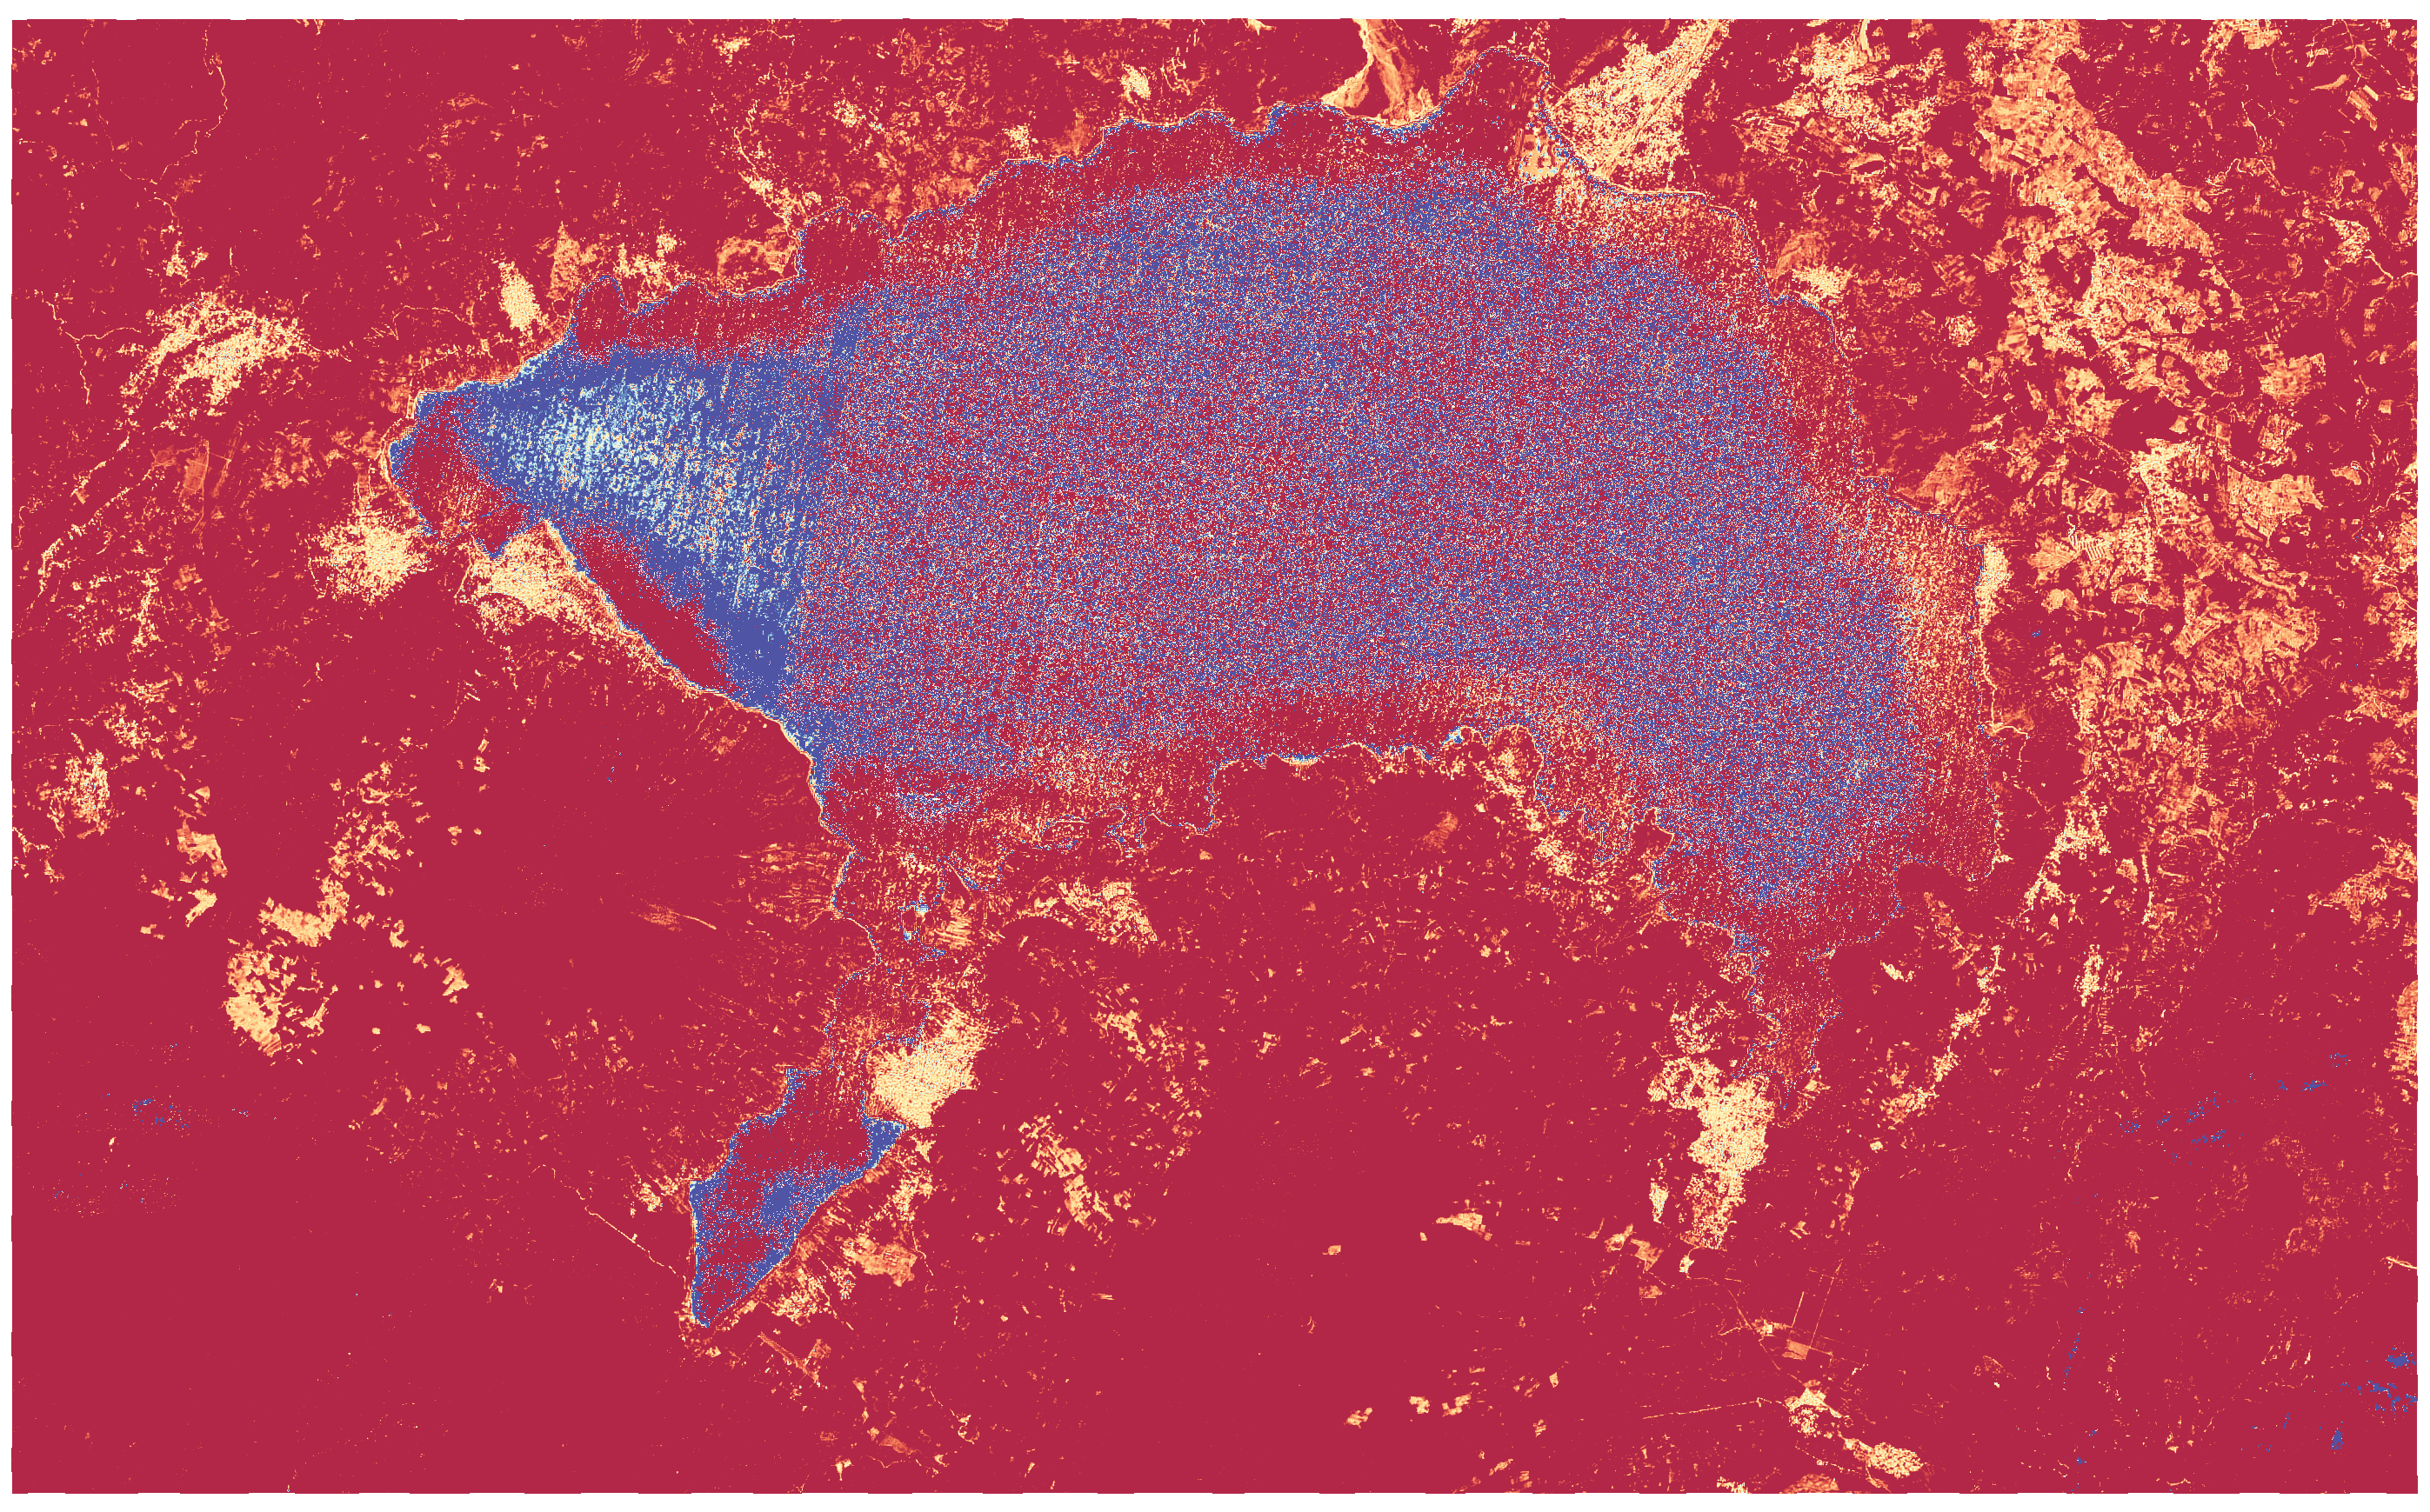

Amatitlan: mapa interactivo para 2026-06-19 guardado en mapa_ndci_Amatitlan_2026-06-19.html



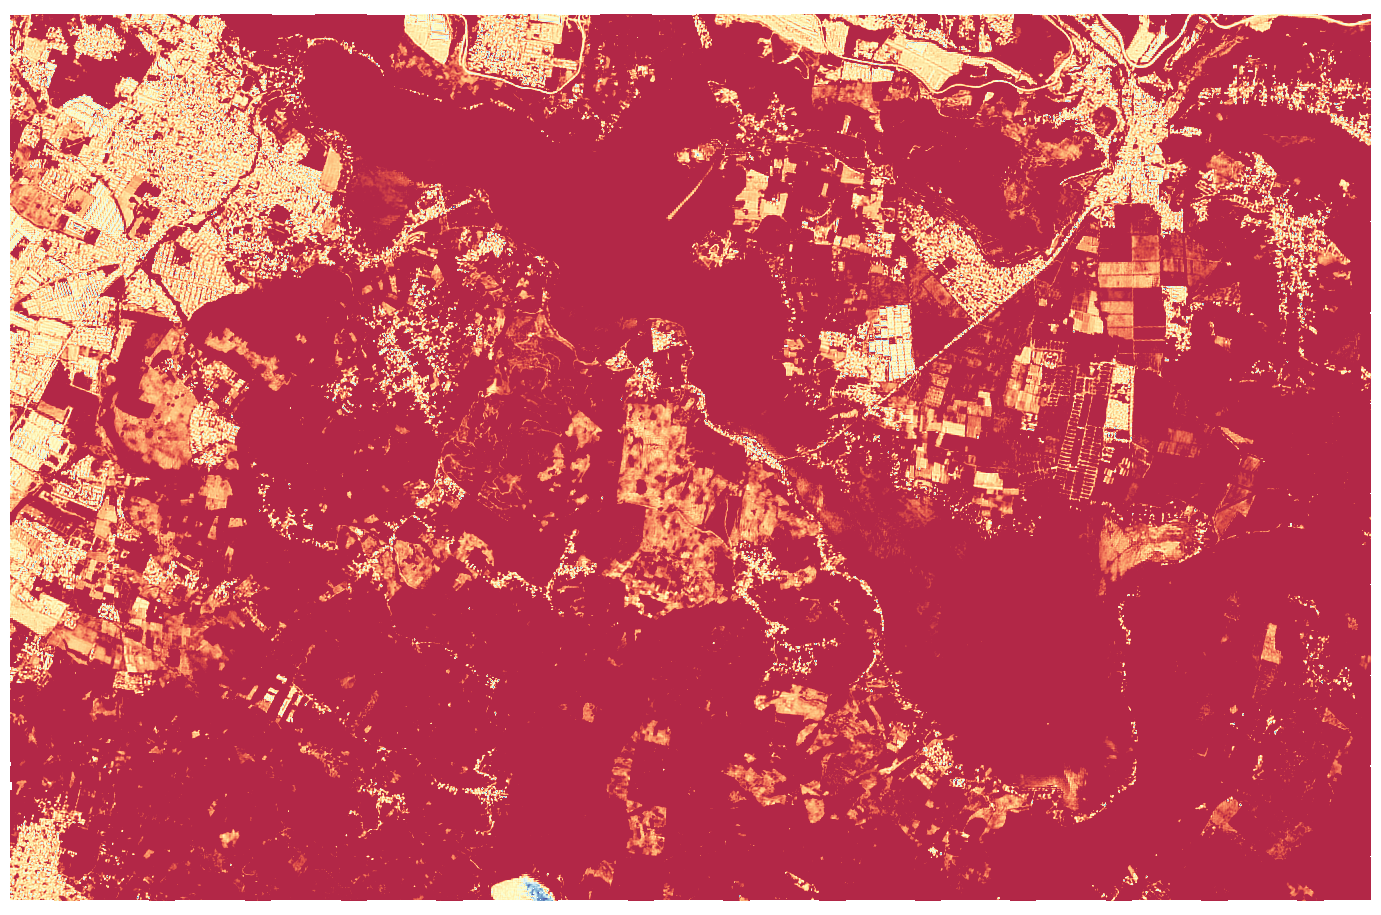

In [12]:
NDCI_VMIN, NDCI_VMAX = -0.3, 0.3
NDCI_CMAP = matplotlib.colormaps["RdYlBu_r"]

def to_latlon_rgba(ndci, valid, src_transform, src_crs, vmin=NDCI_VMIN, vmax=NDCI_VMAX):
    dst_crs = "EPSG:4326"
    west, south, east, north = array_bounds(ndci.shape[0], ndci.shape[1], src_transform)
    dst_transform, width, height = calculate_default_transform(
        src_crs, dst_crs, ndci.shape[1], ndci.shape[0], west, south, east, north,
    )
    dst_ndci = reproject_to_reference(ndci, src_transform, src_crs, dst_transform, dst_crs, (height, width),
                                       WarpResampling.bilinear)
    dst_valid = reproject_to_reference(valid.astype(np.float32), src_transform, src_crs, dst_transform, dst_crs,
                                        (height, width), WarpResampling.nearest, fill_value=0.0) > 0.5
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    rgba = NDCI_CMAP(norm(np.nan_to_num(dst_ndci, nan=vmin)))
    rgba[..., 3] = np.where(dst_valid & np.isfinite(dst_ndci), 0.85, 0.0)
    rgba_uint8 = (rgba * 255).astype(np.uint8)
    dst_west, dst_south, dst_east, dst_north = array_bounds(height, width, dst_transform)
    return rgba_uint8, [[dst_south, dst_west], [dst_north, dst_east]]

def build_ndci_folium_map(lake_name, date_text):
    indices = processed[(lake_name, date_text)]
    image, bounds = to_latlon_rgba(indices["ndci"], indices["valid"], indices["transform"], indices["crs"])
    center = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2]
    fmap = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")
    folium.raster_layers.ImageOverlay(
        image=image, bounds=bounds, opacity=1.0, name=f"NDCI {date_text}",
    ).add_to(fmap)
    colormap = LinearColormap(
        colors=[mcolors.to_hex(NDCI_CMAP(i / 255)) for i in range(0, 256, 32)],
        vmin=NDCI_VMIN, vmax=NDCI_VMAX, caption="NDCI (índice de cianobacteria)",
    )
    colormap.add_to(fmap)
    folium.LayerControl().add_to(fmap)
    return fmap

peak_dates = {}
for lake_name in LAKES:
    peak_row = summary.loc[summary["lake"] == lake_name].sort_values("ndci_mean", ascending=False).iloc[0]
    peak_dates[lake_name] = peak_row["date"].strftime("%Y-%m-%d")
    fmap = build_ndci_folium_map(lake_name, peak_dates[lake_name])
    out_path = DATA_DIR / f"mapa_ndci_{lake_name}_{peak_dates[lake_name]}.html"
    fmap.save(str(out_path))
    print(f"{lake_name}: mapa interactivo para {peak_dates[lake_name]} guardado en {out_path.name}")
    display(fmap)

### 5.2 Mapas comparativos entre fechas

Se grafican los 11 mapas oficiales de cada lago con la misma escala de color (usando la grilla alineada `ALIGNED`) para poder comparar visualmente la intensidad y extensión del NDCI a lo largo del tiempo.

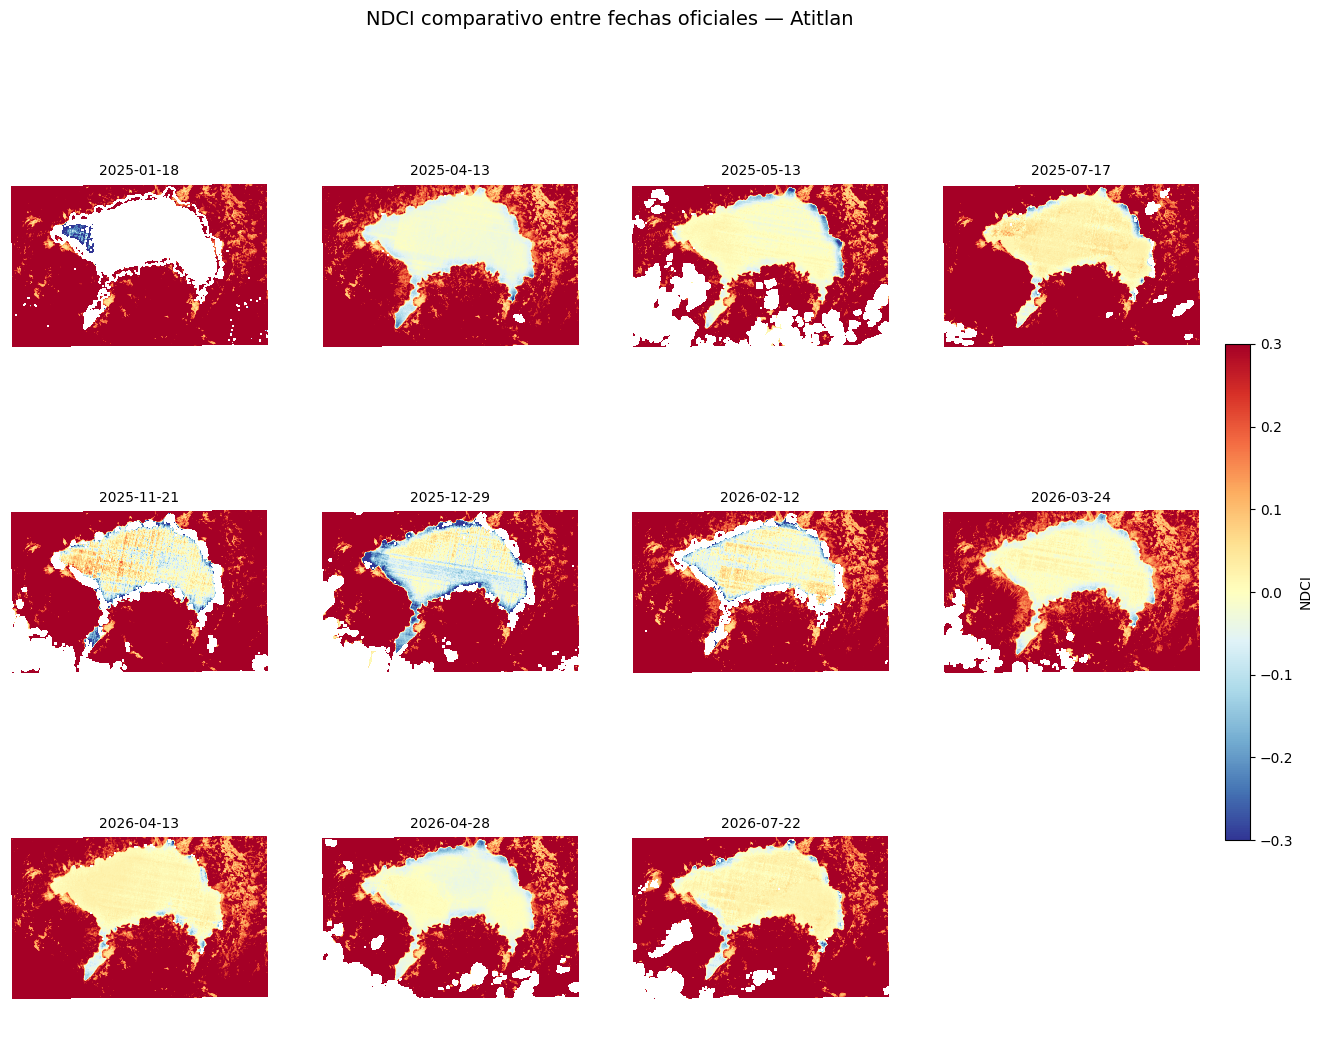

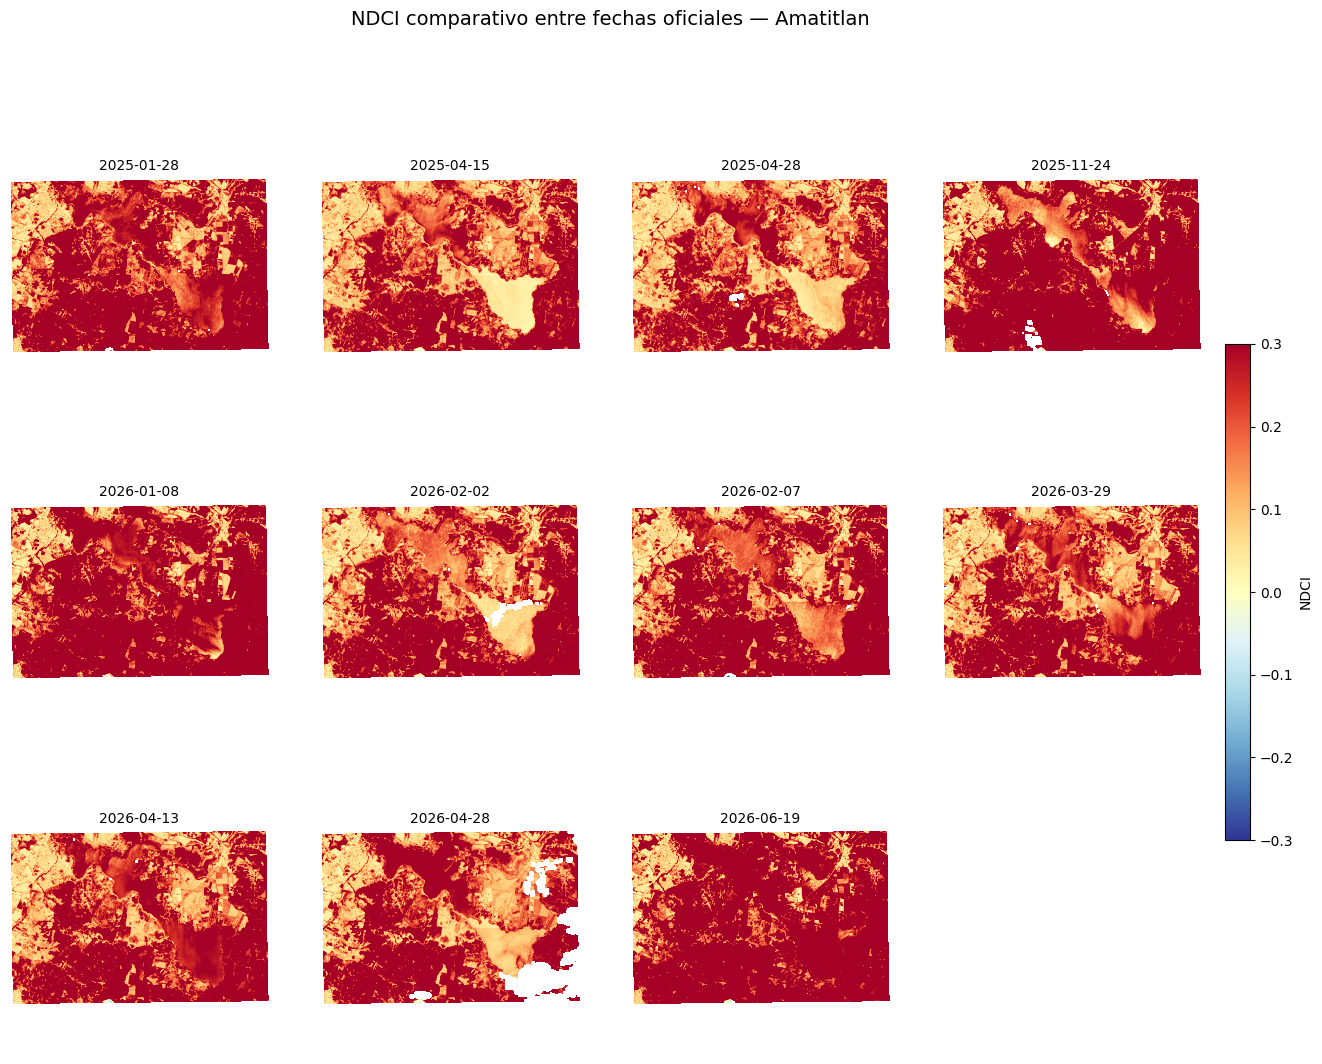

In [13]:
def plot_comparative_maps(lake_name, ncols=4):
    dates_sorted = OFFICIAL_DATES[lake_name]
    nrows = int(np.ceil(len(dates_sorted) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
    im = None
    for i, date_text in enumerate(dates_sorted):
        row, col = divmod(i, ncols)
        ax = axes[row, col]
        data = ALIGNED[lake_name]["dates"][date_text]
        image = np.where(data["valid"], data["ndci"], np.nan)
        im = ax.imshow(image, cmap="RdYlBu_r", vmin=NDCI_VMIN, vmax=NDCI_VMAX)
        ax.set_title(date_text, fontsize=10)
        ax.axis("off")
    for j in range(len(dates_sorted), nrows * ncols):
        row, col = divmod(j, ncols)
        axes[row, col].axis("off")
    fig.suptitle(f"NDCI comparativo entre fechas oficiales — {lake_name}", fontsize=14)
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="NDCI")
    fig.savefig(DATA_DIR / f"mapas_comparativos_{lake_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

for lake_name in LAKES:
    plot_comparative_maps(lake_name)

### 5.3 Patrón espacial promedio: ¿en qué zona del lago se concentra más la cianobacteria?

Se promedia el NDCI de todas las fechas oficiales (grilla alineada) y se compara el valor medio entre los cuatro cuadrantes geográficos del lago (noroeste, noreste, suroeste, sureste) para identificar si existe una zona de acumulación dominante.

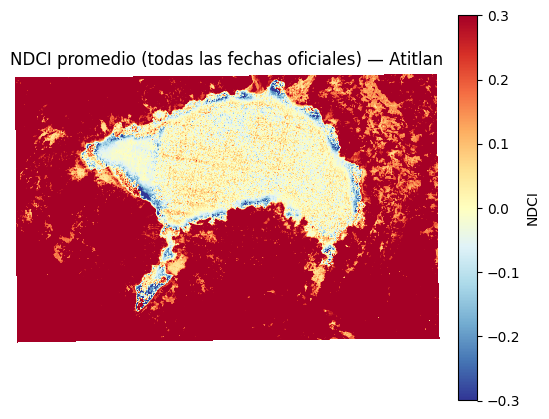

,ndci_promedio
quadrant,
suroeste,0.398704
sureste,0.392665
noroeste,0.234845
noreste,0.160515


Atitlan: la mayor concentración promedio de cianobacteria se ubica en el cuadrante suroeste (NDCI medio=0.399); el cuadrante con menor concentración es noreste (NDCI medio=0.161).


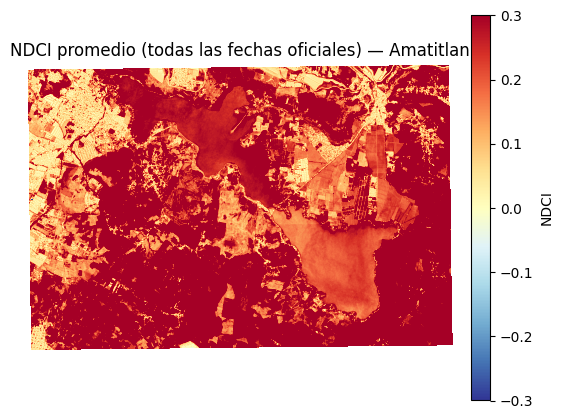

,ndci_promedio
quadrant,
sureste,0.337423
suroeste,0.334118
noreste,0.268282
noroeste,0.223192


Amatitlan: la mayor concentración promedio de cianobacteria se ubica en el cuadrante sureste (NDCI medio=0.337); el cuadrante con menor concentración es noroeste (NDCI medio=0.223).


In [14]:
def quadrant_analysis(lake_name):
    dates_data = ALIGNED[lake_name]["dates"]
    ndci_stack = np.stack([d["ndci"] for d in dates_data.values()])
    valid_stack = np.stack([d["valid"] for d in dates_data.values()])
    mean_map = np.where(valid_stack.any(axis=0), np.nanmean(np.where(valid_stack, ndci_stack, np.nan), axis=0), np.nan)

    n_rows, n_cols = ALIGNED[lake_name]["shape"]
    rows, cols = np.indices((n_rows, n_cols))
    row_mid, col_mid = n_rows / 2, n_cols / 2
    # Raster north-up: fila 0 = norte, columna 0 = oeste.
    quadrant = np.select(
        [(rows < row_mid) & (cols < col_mid), (rows < row_mid) & (cols >= col_mid), (rows >= row_mid) & (cols < col_mid)],
        ["noroeste", "noreste", "suroeste"], default="sureste",
    )
    finite = np.isfinite(mean_map)
    q_stats = pd.DataFrame({"quadrant": quadrant[finite], "ndci": mean_map[finite]}).groupby("quadrant")["ndci"].mean().sort_values(ascending=False)
    return mean_map, q_stats

for lake_name in LAKES:
    mean_map, q_stats = quadrant_analysis(lake_name)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mean_map, cmap="RdYlBu_r", vmin=NDCI_VMIN, vmax=NDCI_VMAX)
    ax.set_title(f"NDCI promedio (todas las fechas oficiales) — {lake_name}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="NDCI")
    fig.savefig(DATA_DIR / f"ndci_promedio_{lake_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    display(q_stats.to_frame("ndci_promedio"))
    top_q, low_q = q_stats.index[0], q_stats.index[-1]
    print(f"{lake_name}: la mayor concentración promedio de cianobacteria se ubica en el cuadrante {top_q} "
          f"(NDCI medio={q_stats.iloc[0]:.3f}); el cuadrante con menor concentración es {low_q} "
          f"(NDCI medio={q_stats.iloc[-1]:.3f}).")

## Ejercicio 6. Correlación de NDVI y NDWI con la cianobacteria

Se calcula la correlación de Pearson a nivel de píxel (agrupando todos los píxeles válidos de todas las fechas oficiales por lago) entre el NDCI y cada uno de los otros dos índices. Trabajar a nivel de píxel, en vez de solo con los 11 promedios por fecha, da una muestra mucho más grande y una estimación más robusta de la relación real dentro del lago.

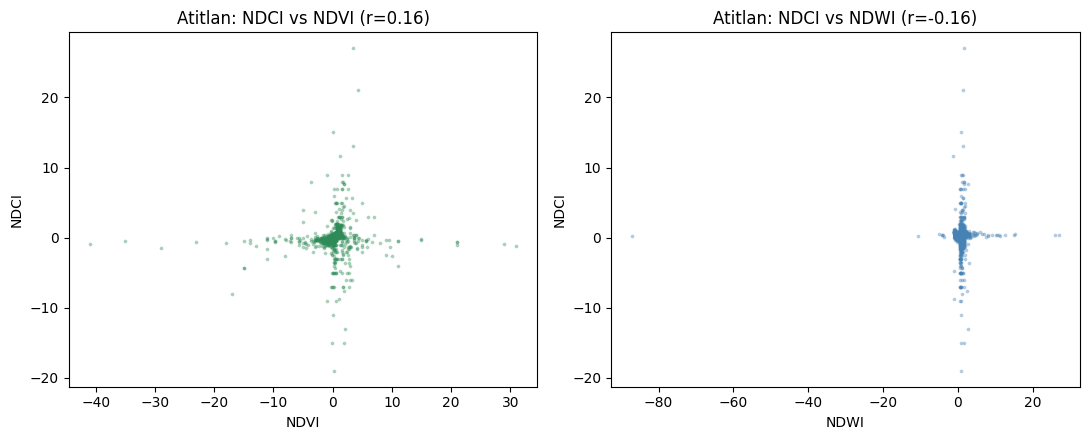

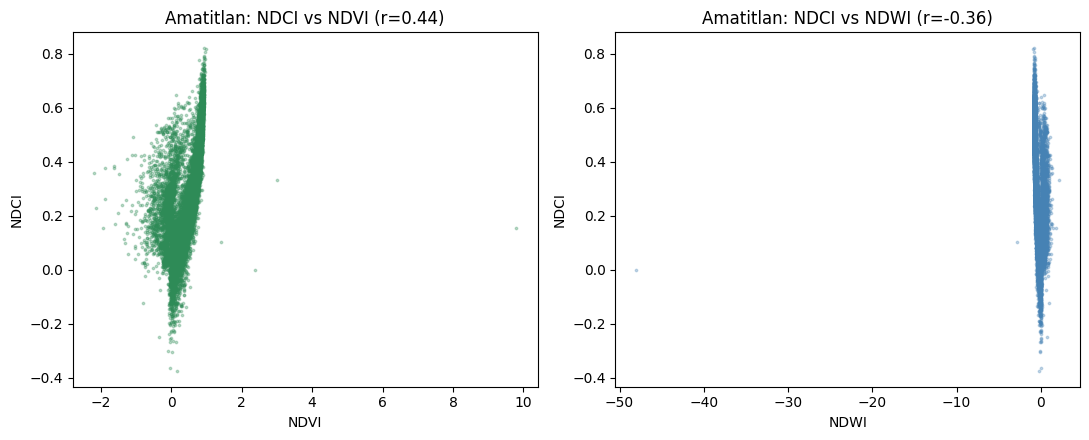

,lake,n_pixels,r_ndci_ndvi,r_ndci_ndwi
0,Atitlan,49651039,0.157406,-0.164605
1,Amatitlan,13294722,0.444151,-0.364474


Atitlan: correlación NDCI-NDVI positiva y débil (r=0.16); correlación NDCI-NDWI negativa y débil (r=-0.16), con n=49651039 píxeles válidos agrupados de las 11 fechas oficiales.
Amatitlan: correlación NDCI-NDVI positiva y moderada (r=0.44); correlación NDCI-NDWI negativa y moderada (r=-0.36), con n=13294722 píxeles válidos agrupados de las 11 fechas oficiales.


In [15]:
def strength_label(r):
    magnitude = abs(r)
    if magnitude < 0.2:
        return "débil"
    if magnitude < 0.5:
        return "moderada"
    return "fuerte"

rng = np.random.default_rng(42)
correlation_records = []
for lake_name in LAKES:
    ndci_all, ndvi_all, ndwi_all = [], [], []
    for date_text in OFFICIAL_DATES[lake_name]:
        indices = processed[(lake_name, date_text)]
        mask = indices["valid"]
        ndci_all.append(indices["ndci"][mask])
        ndvi_all.append(indices["ndvi"][mask])
        ndwi_all.append(indices["ndwi"][mask])
    ndci_all = np.concatenate(ndci_all)
    ndvi_all = np.concatenate(ndvi_all)
    ndwi_all = np.concatenate(ndwi_all)

    r_ndvi = float(np.corrcoef(ndci_all, ndvi_all)[0, 1])
    r_ndwi = float(np.corrcoef(ndci_all, ndwi_all)[0, 1])
    correlation_records.append({"lake": lake_name, "n_pixels": ndci_all.size, "r_ndci_ndvi": r_ndvi, "r_ndci_ndwi": r_ndwi})

    sample_idx = rng.choice(ndci_all.size, size=min(20000, ndci_all.size), replace=False)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].scatter(ndvi_all[sample_idx], ndci_all[sample_idx], s=3, alpha=0.3, color="seagreen")
    axes[0].set_xlabel("NDVI"); axes[0].set_ylabel("NDCI")
    axes[0].set_title(f"{lake_name}: NDCI vs NDVI (r={r_ndvi:.2f})")
    axes[1].scatter(ndwi_all[sample_idx], ndci_all[sample_idx], s=3, alpha=0.3, color="steelblue")
    axes[1].set_xlabel("NDWI"); axes[1].set_ylabel("NDCI")
    axes[1].set_title(f"{lake_name}: NDCI vs NDWI (r={r_ndwi:.2f})")
    fig.tight_layout()
    fig.savefig(DATA_DIR / f"correlacion_{lake_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

correlation_df = pd.DataFrame(correlation_records)
correlation_df.to_csv(DATA_DIR / "correlaciones_ndci.csv", index=False)
display(correlation_df)

for rec in correlation_records:
    sign_ndvi = "positiva" if rec["r_ndci_ndvi"] > 0 else "negativa"
    sign_ndwi = "positiva" if rec["r_ndci_ndwi"] > 0 else "negativa"
    print(f"{rec['lake']}: correlación NDCI-NDVI {sign_ndvi} y {strength_label(rec['r_ndci_ndvi'])} "
          f"(r={rec['r_ndci_ndvi']:.2f}); correlación NDCI-NDWI {sign_ndwi} y {strength_label(rec['r_ndci_ndwi'])} "
          f"(r={rec['r_ndci_ndwi']:.2f}), con n={rec['n_pixels']} píxeles válidos agrupados de las 11 fechas oficiales.")

## Ejercicio 7. Análisis y comparación de los lagos

### 7.1-7.2 Estadísticas de proliferación e intensidad/frecuencia de floración

Se resume, por lago: el NDCI promedio del período, su variabilidad, el máximo observado, la fecha pico, el porcentaje de fechas oficiales que superan el umbral exploratorio, la extensión espacial media de floración, y la tendencia lineal (pendiente de NDCI promedio por día) a lo largo del período estudiado.

,ndci_mean_avg,ndci_mean_std,ndci_mean_max,fecha_pico,pct_fechas_sobre_umbral,extension_media_pct,tendencia_ndci_por_dia
lake,,,,,,,
Amatitlan,0.289818,0.056643,0.395384,2026-06-19,100.0,64.822167,0.000116
Atitlan,0.286834,0.039532,0.360786,2025-01-18,100.0,64.190373,-0.000083


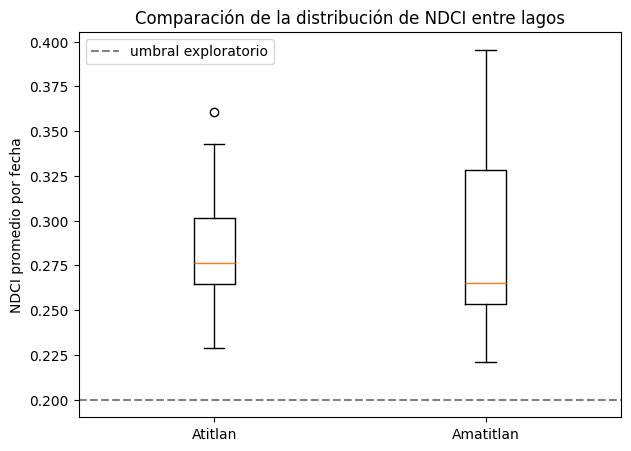

El lago con mayor intensidad promedio de cianobacteria es Amatitlan (NDCI medio=0.290).
El lago con mayor frecuencia de fechas sobre el umbral exploratorio es Amatitlan (100.0% de las 11 fechas oficiales).
Atitlan: la tendencia lineal del NDCI promedio en el período estudiado muestra una disminución (pendiente=-8.31e-05 NDCI/día).
Amatitlan: la tendencia lineal del NDCI promedio en el período estudiado muestra un incremento (pendiente=1.16e-04 NDCI/día).


In [16]:
def linear_trend_per_day(dates, values):
    dates = pd.to_datetime(pd.Series(dates).reset_index(drop=True))
    x = (dates - dates.min()).dt.days.values.astype(float)
    slope, _ = np.polyfit(x, values, 1)
    return float(slope)

lake_stats_records = []
for lake_name, group in summary.groupby("lake"):
    group = group.sort_values("date")
    slope = linear_trend_per_day(group["date"], group["ndci_mean"].values)
    lake_stats_records.append({
        "lake": lake_name,
        "ndci_mean_avg": group["ndci_mean"].mean(),
        "ndci_mean_std": group["ndci_mean"].std(),
        "ndci_mean_max": group["ndci_mean"].max(),
        "fecha_pico": group.loc[group["ndci_mean"].idxmax(), "date"].strftime("%Y-%m-%d"),
        "pct_fechas_sobre_umbral": 100 * (group["ndci_mean"] >= NDCI_HIGH_THRESHOLD).mean(),
        "extension_media_pct": 100 * group["ndci_high_fraction"].mean(),
        "tendencia_ndci_por_dia": slope,
    })
lake_stats_df = pd.DataFrame(lake_stats_records).set_index("lake")
lake_stats_df.to_csv(DATA_DIR / "comparacion_lagos.csv")
display(lake_stats_df)

fig, ax = plt.subplots(figsize=(7, 5))
box_data = [summary.loc[summary["lake"] == lake_name, "ndci_mean"] for lake_name in LAKES]
ax.boxplot(box_data, tick_labels=list(LAKES.keys()))
ax.axhline(NDCI_HIGH_THRESHOLD, color="gray", linestyle="--", label="umbral exploratorio")
ax.set_ylabel("NDCI promedio por fecha")
ax.set_title("Comparación de la distribución de NDCI entre lagos")
ax.legend()
fig.savefig(DATA_DIR / "boxplot_comparacion_lagos.png", dpi=150, bbox_inches="tight")
plt.show()

more_intense = lake_stats_df["ndci_mean_avg"].idxmax()
more_frequent = lake_stats_df["pct_fechas_sobre_umbral"].idxmax()
print(f"El lago con mayor intensidad promedio de cianobacteria es {more_intense} "
      f"(NDCI medio={lake_stats_df.loc[more_intense, 'ndci_mean_avg']:.3f}).")
print(f"El lago con mayor frecuencia de fechas sobre el umbral exploratorio es {more_frequent} "
      f"({lake_stats_df.loc[more_frequent, 'pct_fechas_sobre_umbral']:.1f}% de las 11 fechas oficiales).")
for lake_name in LAKES:
    slope = lake_stats_df.loc[lake_name, "tendencia_ndci_por_dia"]
    tendencia = "un incremento" if slope > 0 else "una disminución" if slope < 0 else "estabilidad"
    print(f"{lake_name}: la tendencia lineal del NDCI promedio en el período estudiado muestra {tendencia} "
          f"(pendiente={slope:.2e} NDCI/día).")

### 7.3-7.4 Diferencias entre lagos: posibles causas de la proliferación

Al redactar el informe, conecte los números impresos arriba (`lake_stats_df`, el boxplot y las correlaciones de la sección 6) con el contexto geográfico y de uso del suelo de cada lago:

- **Atitlán** es un lago profundo de origen volcánico (caldera), rodeado principalmente de bosque y agricultura de ladera, con una cuenca menos densamente urbanizada, aunque con presión creciente de aguas residuales de los municipios costeros y turismo.
- **Amatitlán** es un lago somero ubicado en el extremo sur del área metropolitana de Ciudad de Guatemala; su cuenca recibe descargas de aguas residuales domésticas e industriales de una población mucho mayor, además de escorrentía agrícola, lo que históricamente lo ha hecho más eutrófico.

Use esa diferencia de profundidad, presión urbana y carga de nutrientes para explicar por qué un lago puede mostrar valores de NDCI más altos, más frecuentes o más variables que el otro, apoyándose siempre en las cifras concretas obtenidas (no solo en la descripción general).

## Ejercicio 8. Análisis exploratorio adicional

### 8.1 Extensión espacial de la floración por fecha

`ndci_high_fraction` (calculado en el ejercicio 3) ya contiene, para cada fecha, la fracción de píxeles válidos del lago con NDCI ≥ umbral exploratorio. Se visualiza su evolución y se resume con media y máximo por lago.

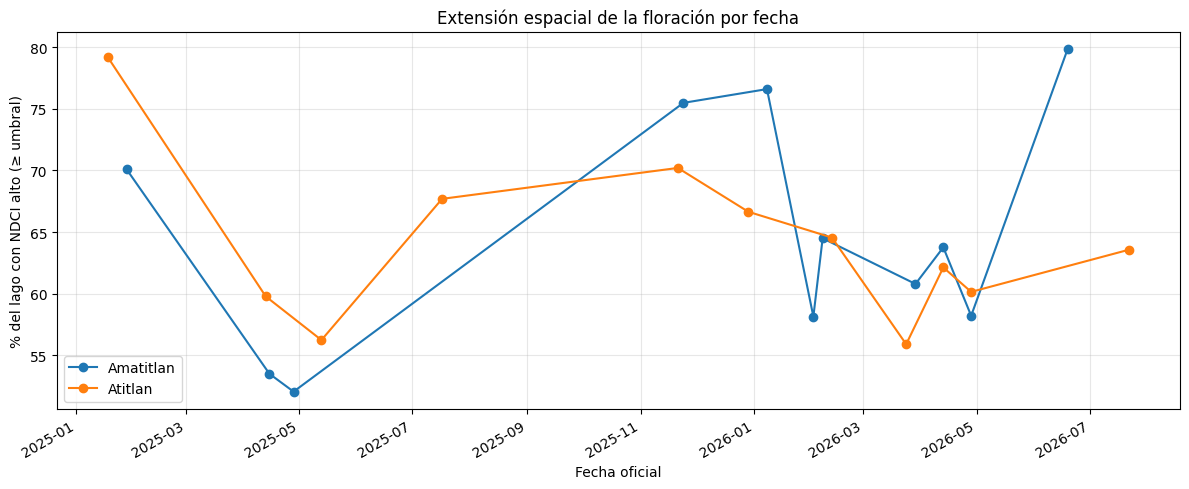

,extension_media_pct,extension_maxima_pct
lake,,
Amatitlan,64.822167,79.846839
Atitlan,64.190373,79.163068


Atitlan: en promedio el 64.2% del lago mostró NDCI alto, con un máximo de 79.2% en la fecha más crítica.
Amatitlan: en promedio el 64.8% del lago mostró NDCI alto, con un máximo de 79.8% en la fecha más crítica.


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
for lake_name, group in summary.groupby("lake"):
    group = group.sort_values("date")
    ax.plot(group["date"], 100 * group["ndci_high_fraction"], marker="o", label=lake_name)
ax.set_ylabel("% del lago con NDCI alto (≥ umbral)")
ax.set_xlabel("Fecha oficial")
ax.set_title("Extensión espacial de la floración por fecha")
ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(DATA_DIR / "extension_espacial_floracion.png", dpi=150, bbox_inches="tight")
plt.show()

ext_stats = (100 * summary.groupby("lake")["ndci_high_fraction"].agg(["mean", "max"])).rename(
    columns={"mean": "extension_media_pct", "max": "extension_maxima_pct"}
)
display(ext_stats)
for lake_name in LAKES:
    print(f"{lake_name}: en promedio el {ext_stats.loc[lake_name, 'extension_media_pct']:.1f}% del lago mostró NDCI alto, "
          f"con un máximo de {ext_stats.loc[lake_name, 'extension_maxima_pct']:.1f}% en la fecha más crítica.")

### 8.2 Zonas persistentes de acumulación

Usando la grilla alineada (`ALIGNED`), se calcula, píxel a píxel, en qué fracción de las fechas oficiales válidas ese píxel tuvo NDCI ≥ umbral. Un valor cercano a 1 indica una zona que floreció casi siempre que hubo observación válida: una zona persistente de acumulación, en vez de una floración puntual y pasajera.

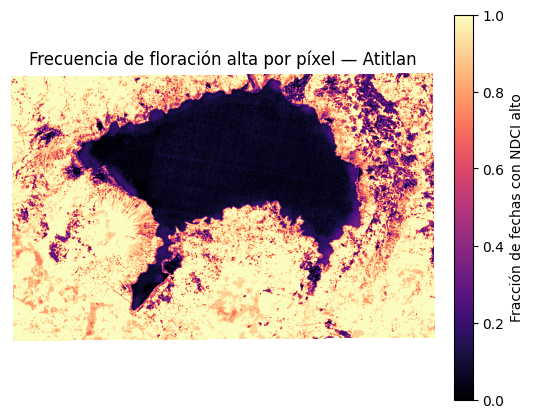

Atitlan: 63.9% del área del lago tuvo NDCI alto en al menos la mitad de las fechas oficiales con observación válida (zona persistente de acumulación).


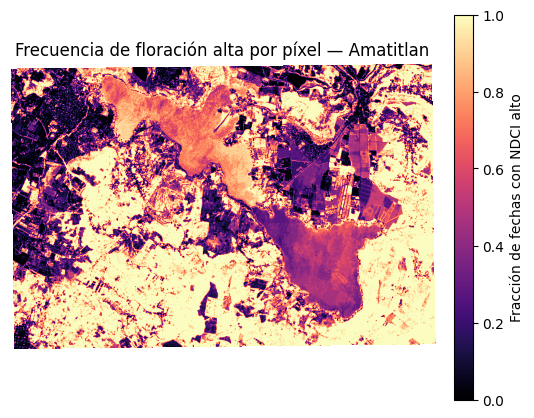

Amatitlan: 63.9% del área del lago tuvo NDCI alto en al menos la mitad de las fechas oficiales con observación válida (zona persistente de acumulación).


In [18]:
persistent_maps = {}
for lake_name in LAKES:
    dates_data = ALIGNED[lake_name]["dates"]
    ndci_stack = np.stack([d["ndci"] for d in dates_data.values()])
    valid_stack = np.stack([d["valid"] for d in dates_data.values()])
    high_stack = (ndci_stack >= NDCI_HIGH_THRESHOLD) & valid_stack
    n_valid = valid_stack.sum(axis=0)
    freq_map = np.divide(high_stack.sum(axis=0), n_valid, out=np.full(n_valid.shape, np.nan, dtype=np.float32), where=n_valid > 0)
    persistent_maps[lake_name] = freq_map

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(freq_map, cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"Frecuencia de floración alta por píxel — {lake_name}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Fracción de fechas con NDCI alto")
    fig.savefig(DATA_DIR / f"zonas_persistentes_{lake_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    pct_persistent = 100 * np.nanmean(freq_map >= 0.5)
    print(f"{lake_name}: {pct_persistent:.1f}% del área del lago tuvo NDCI alto en al menos la mitad de las fechas "
          f"oficiales con observación válida (zona persistente de acumulación).")

### 8.3 Comparación de la distribución de valores entre fechas

Se muestra, por lago, un boxplot del NDCI píxel a píxel en cada fecha oficial (para ver cómo cambia toda la distribución, no solo el promedio) y un mapa de diferencia entre la fecha de mayor NDCI promedio (pico) y la primera fecha oficial, usando la grilla alineada para que la resta sea píxel a píxel válida.

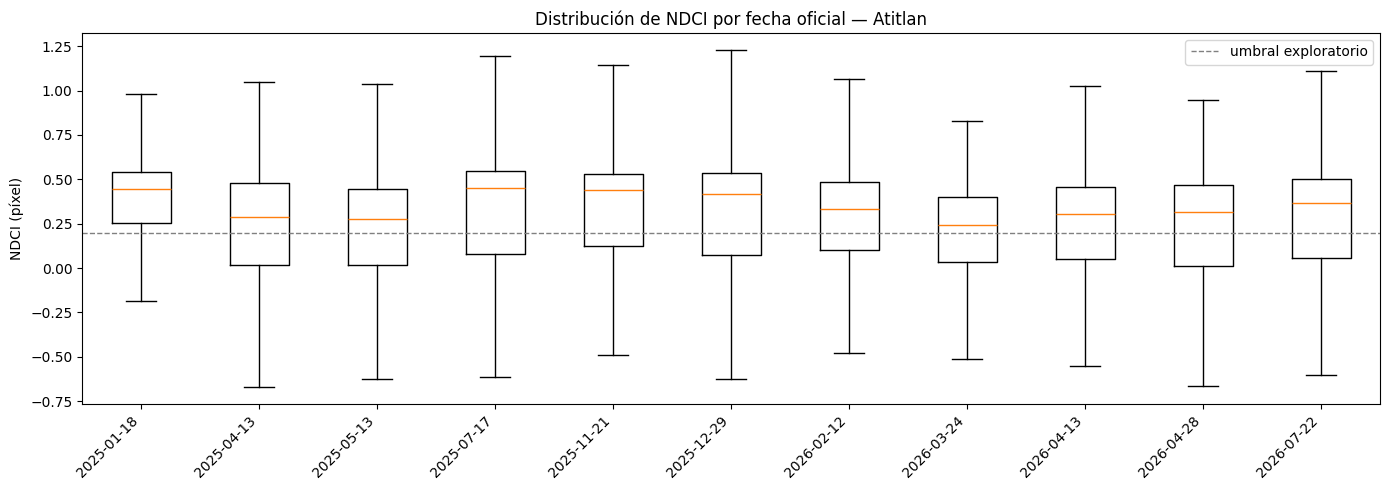

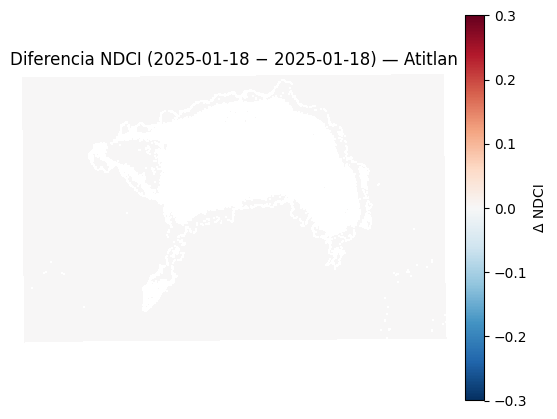

Atitlan: entre 2025-01-18 y el pico (2025-01-18) el NDCI subió en promedio +0.000 en los píxeles comunes válidos; 0.0% del área comparada aumentó su NDCI.


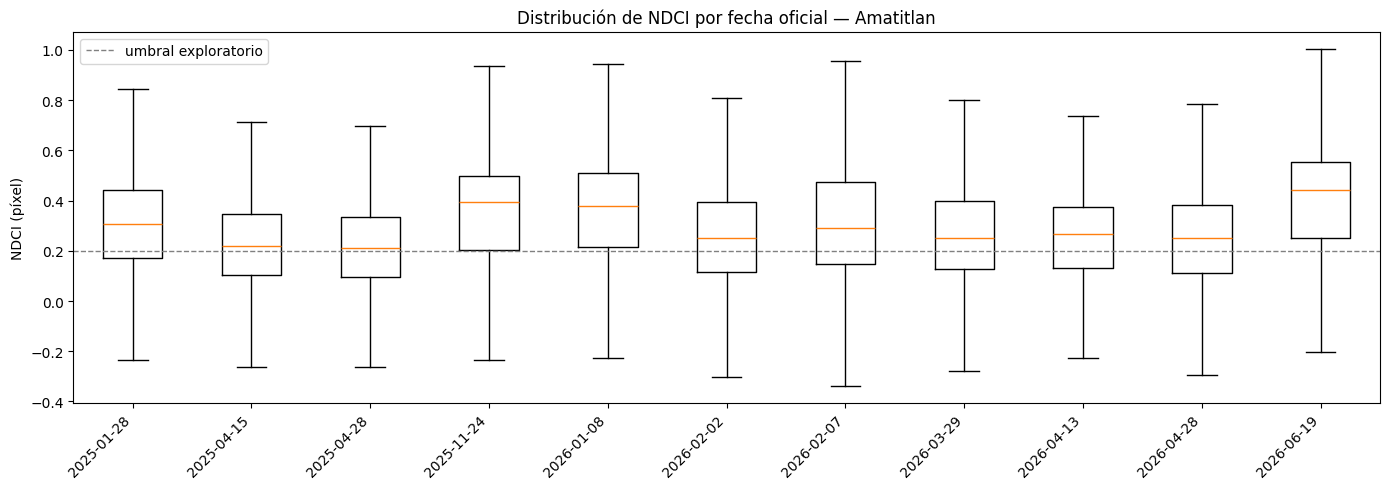

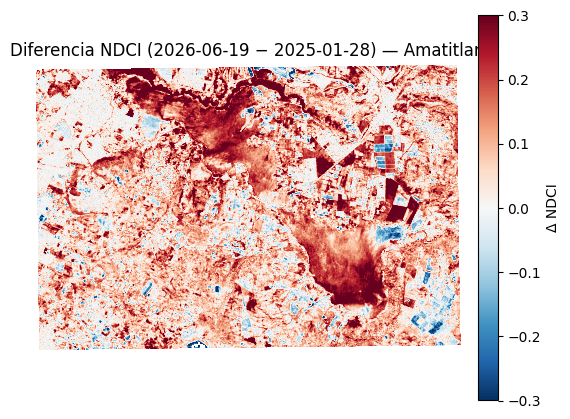

Amatitlan: entre 2025-01-28 y el pico (2026-06-19) el NDCI subió en promedio +0.093 en los píxeles comunes válidos; 73.1% del área comparada aumentó su NDCI.


In [19]:
for lake_name in LAKES:
    dates_data = ALIGNED[lake_name]["dates"]
    labels = list(dates_data.keys())
    box_data = [dates_data[d]["ndci"][dates_data[d]["valid"]] for d in labels]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.boxplot(box_data, tick_labels=labels, showfliers=False)
    ax.axhline(NDCI_HIGH_THRESHOLD, color="gray", linestyle="--", linewidth=1, label="umbral exploratorio")
    ax.set_ylabel("NDCI (píxel)")
    ax.set_title(f"Distribución de NDCI por fecha oficial — {lake_name}")
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(DATA_DIR / f"boxplot_fechas_{lake_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    first_date = OFFICIAL_DATES[lake_name][0]
    peak_date = peak_dates[lake_name]
    first_d, peak_d = dates_data[first_date], dates_data[peak_date]
    common_valid = first_d["valid"] & peak_d["valid"]
    diff_map = np.where(common_valid, peak_d["ndci"] - first_d["ndci"], np.nan)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(diff_map, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
    ax.set_title(f"Diferencia NDCI ({peak_date} − {first_date}) — {lake_name}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Δ NDCI")
    fig.savefig(DATA_DIR / f"mapa_diferencia_{lake_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"{lake_name}: entre {first_date} y el pico ({peak_date}) el NDCI subió en promedio "
          f"{np.nanmean(diff_map):+.3f} en los píxeles comunes válidos; "
          f"{100 * np.nanmean(diff_map > 0):.1f}% del área comparada aumentó su NDCI.")

### 8.4 Patrón estacional

Guatemala tiene dos temporadas climáticas marcadas: seca (noviembre-abril) y lluviosa (mayo-octubre). Se agrupan las fechas oficiales según esa temporada y se compara el NDCI promedio entre ambas, por lago, para explorar si la proliferación de cianobacteria muestra un patrón estacional.

ndci_mean_promedio  count
lake      temporada                                    
Amatitlan lluviosa (may-oct)            0.395384      1
          seca (nov-abr)                0.279262     10
Atitlan   lluviosa (may-oct)            0.294903      3
          seca (nov-abr)                0.283808      8

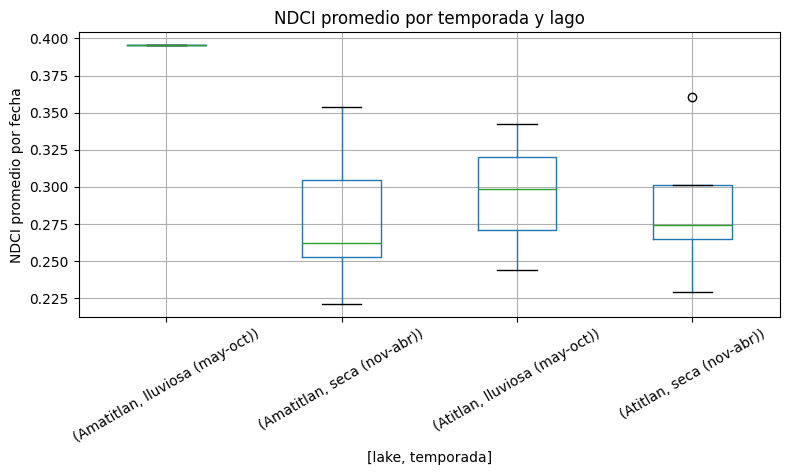

Atitlan: el NDCI promedio es mayor en temporada lluviosa (diferencia=0.011 respecto a la otra temporada).
Amatitlan: el NDCI promedio es mayor en temporada lluviosa (diferencia=0.116 respecto a la otra temporada).


In [20]:
def season_of(month):
    return "seca (nov-abr)" if month in (11, 12, 1, 2, 3, 4) else "lluviosa (may-oct)"

summary["temporada"] = summary["date"].dt.month.apply(season_of)
season_stats = summary.groupby(["lake", "temporada"])["ndci_mean"].agg(["mean", "count"]).rename(columns={"mean": "ndci_mean_promedio"})
display(season_stats)

fig, ax = plt.subplots(figsize=(8, 5))
summary.boxplot(column="ndci_mean", by=["lake", "temporada"], ax=ax, rot=30)
plt.suptitle("")
ax.set_title("NDCI promedio por temporada y lago")
ax.set_ylabel("NDCI promedio por fecha")
fig.tight_layout()
fig.savefig(DATA_DIR / "patron_estacional.png", dpi=150, bbox_inches="tight")
plt.show()

for lake_name in LAKES:
    sub = season_stats.loc[lake_name]
    if "seca (nov-abr)" in sub.index and "lluviosa (may-oct)" in sub.index:
        diff_season = sub.loc["seca (nov-abr)", "ndci_mean_promedio"] - sub.loc["lluviosa (may-oct)", "ndci_mean_promedio"]
        mayor = "seca" if diff_season > 0 else "lluviosa"
        print(f"{lake_name}: el NDCI promedio es mayor en temporada {mayor} "
              f"(diferencia={abs(diff_season):.3f} respecto a la otra temporada).")
    else:
        print(f"{lake_name}: no hay fechas oficiales en ambas temporadas, no se puede comparar directamente.")

### 8.5 Síntesis e insumos para el informe final

Todos los resultados numéricos y gráficos anteriores (extensión espacial por fecha, zonas persistentes, distribución por fecha, mapas de diferencia y patrón estacional) deben interpretarse en conjunto en el informe dirigido a los ambientalistas: qué tan extendida y persistente es la floración en cada lago, si hay zonas fijas de acumulación (relevante para priorizar monitoreo o intervención), cómo cambia la distribución completa de valores (no solo el promedio) entre fechas, y si existe estacionalidad relacionada con el clima. La celda siguiente lista los archivos generados en `data/GIS/lab4_avance` que respaldan cada hallazgo.

In [21]:
generated_files = sorted(
    p.name for p in DATA_DIR.glob("*") if p.is_file() and p.suffix in (".png", ".csv", ".html")
)
print(f"Archivos generados para el informe ({len(generated_files)}) en {DATA_DIR.resolve()}:")
for name in generated_files:
    print(f" - {name}")

Archivos generados para el informe (22) en /Users/dijan/Documents/U/Data Science/Lab4/data/GIS/lab4_avance:
 - boxplot_comparacion_lagos.png
 - boxplot_fechas_Amatitlan.png
 - boxplot_fechas_Atitlan.png
 - comparacion_lagos.csv
 - correlacion_Amatitlan.png
 - correlacion_Atitlan.png
 - correlaciones_ndci.csv
 - extension_espacial_floracion.png
 - indices_muestra.png
 - mapa_diferencia_Amatitlan.png
 - mapa_diferencia_Atitlan.png
 - mapa_ndci_Amatitlan_2026-06-19.html
 - mapa_ndci_Atitlan_2025-01-18.html
 - mapas_comparativos_Amatitlan.png
 - mapas_comparativos_Atitlan.png
 - ndci_promedio_Amatitlan.png
 - ndci_promedio_Atitlan.png
 - patron_estacional.png
 - resumen_indices_por_fecha.csv
 - serie_temporal_ndci.png
 - zonas_persistentes_Amatitlan.png
 - zonas_persistentes_Atitlan.png
